# Rolling out of Sample Forecast Evaluation

So far we have discussed the performance of every model by making it fit to to all available data and then compared against the same data it was trained on. Clearly, this is not how forecasting actually works. We are trying to predict things we do not have information about when we are predicting them.

The goal of this notebook is to do this properly. All our forecasting models - HVF,EWMA and GARCH will be trained on a historical window and used to forecast the next period. Then the window will roll forwards, what we predicted will be used as historical data and we will repeat the forecast. Hence the name rolling out. 

# Introduction

In the previous notebooks we confirmed that all three models can produce volatility estimates. But all those comparisons were "in sample". The models had already seen the future when they were evaluated. This certainly makes them look better than they actually are, aka, overfitting.

Our rolling out of sample framework fixes this. We split the data into a training period and a testing period. We fit the model on the training data only. We forecast one step ahead. Then we move the window forward by one observation and repeat.

This gives us a time series of genuinely out of sample forecasts. Compute RMSE and MAE in this case is a much more honest discussion to have 

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf
import warnings

from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")
plt.style.use("ggplot")

START = "2005-01-01"

In [2]:
# same data loading as before

spy = yf.download(
    "SPY",
    start=START,
    auto_adjust=True
)

spy["returns"] = np.log(
    spy["Close"] / spy["Close"].shift(1)
)

spy["rv_20"] = (
    spy["returns"]
    .rolling(20)
    .std()
    * np.sqrt(252)
)

spy["target_20d"] = (
    spy["rv_20"]
    .shift(-20)
)

spy = spy.dropna()

spy.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,returns,rv_20,target_20d
Ticker,SPY,SPY,SPY,SPY,SPY,,,
Date,,,,,,,,
2005-02-01,80.236671,80.351381,79.690106,79.791322,49841200,0.006327,0.102257,0.104527
2005-02-02,80.479599,80.695525,80.229938,80.337898,52468900,0.003023,0.093023,0.104248
2005-02-03,80.270432,80.405388,80.007272,80.337907,48837100,-0.002602,0.089854,0.111082
2005-02-04,81.127373,81.262324,80.283913,80.297406,50024600,0.010619,0.095649,0.105820
2005-02-07,81.019440,81.323083,80.945215,81.140898,45412000,-0.001331,0.095620,0.106888


# Setting Up the Rolling Window

Before running any model I need to decide how much data to use for training. There are two choices here. A fixed expanding window uses all data from the start up to the current point. A rolling window uses only a fixed length of recent observations. 

I will use a fixed training window of 1000 observations (four years of trading days). This is large enough to capture multiple volatility regimes but small enough that the model can adapt as conditions change.

In [3]:
TRAIN_SIZE = 1000

n = len(spy)

print(f"Total observations: {n}")
print(f"Training window: {TRAIN_SIZE}")
print(f"Test observations: {n - TRAIN_SIZE}")
print(f"Test period starts: {spy.index[TRAIN_SIZE].date()}")

Total observations: 5359
Training window: 1000
Test observations: 4359
Test period starts: 2009-01-22


## Comments

Finding the right balance is important. A short test window could be dominated by a single market regime and give erroneous conclusions. Our test period spans multiple years and hence should include both calm and stressed market conditions.

# Experiment 1: Rolling Historical Volatility Forecasts

Let us start with our simplest model. At each point in time, the historical volatility forecast is just the mean of the rolling realized volatility over the training window. I have my doubts about performance.

In [4]:
hv_forecasts = []
dates = []

for i in range(TRAIN_SIZE, n):

    train = spy["rv_20"].iloc[i - TRAIN_SIZE:i]

    hv_forecasts.append(train.mean())
    dates.append(spy.index[i])

hv_forecasts = pd.Series(
    hv_forecasts,
    index=dates
)

print(f"HV out of sample forecasts: {len(hv_forecasts)}")

HV out of sample forecasts: 4359


## Comments

Each forecast is generated using only data available before that date. No future information leaks into the estimate. The loop moves forward one day at a time, re estimating the forecast at each step. This is exactly how a live trading system would operate.

# Experiment 2: Rolling EWMA Forecasts

For EWMA the rolling procedure works differently. Instead of re estimating a parameter, I initialise the EWMA recursion at the start of each window and run it forward to the end of the training period. The final estimated variance is then the one step ahead forecast.

I use the standard RiskMetrics lambda of 0.94 which we concluded with in notebook 4.

In [5]:
LAM = 0.94

ewma_forecasts = []

for i in range(TRAIN_SIZE, n):

    train_returns = spy["returns"].iloc[i - TRAIN_SIZE:i]

    var = train_returns.var()

    for r in train_returns:
        var = LAM * var + (1 - LAM) * r**2

    ewma_forecasts.append(
        np.sqrt(var) * np.sqrt(252)
    )

ewma_forecasts = pd.Series(
    ewma_forecasts,
    index=dates
)

print(f"EWMA out of sample forecasts: {len(ewma_forecasts)}")

EWMA out of sample forecasts: 4359


## Comments

The EWMA recursion carries information from earlier observations forward through exponential weighing. The most recent return receives the highest weight. This means the forecast at each step is most sensitive to the most recent market conditions and gets less and less sensitive as distance increasing.

# Experiment 3: Rolling GARCH Forecasts

In GARCH parameters need to be estimated via maximum likelihood at each step. I refit our GARCH(1,1) on each rolling window and extract the one step ahead conditional volatility forecast. This will be slower than other two but hopefully perform much better.

In [6]:
garch_forecasts = []

# this loop is slow because GARCH is refitted at each step

for i in range(TRAIN_SIZE, n):

    train_returns = (
        spy["returns"].iloc[i - TRAIN_SIZE:i] * 100
    )

    try:

        model = arch_model(
            train_returns,
            mean="Zero",
            vol="GARCH",
            p=1,
            q=1
        )

        result = model.fit(disp="off")

        forecast = result.forecast(horizon=1)

        forecast_var = forecast.variance.iloc[-1, 0]

        garch_forecasts.append(
            np.sqrt(forecast_var) / 100 * np.sqrt(252)
        )

    except:

        # if GARCH fails to converge, fall back to EWMA
        garch_forecasts.append(ewma_forecasts.iloc[i - TRAIN_SIZE])

garch_forecasts = pd.Series(
    garch_forecasts,
    index=dates
)

print(f"GARCH out of sample forecasts: {len(garch_forecasts)}")

GARCH out of sample forecasts: 4359


## Comments

Notice we have a try except block. This is because GARCH sometimes does not converge in case of crisis. So when this happen, we go back to EWMA to avoid the loop from breaking. This is somewhat like cheating but at this stage, it is necessary. Hopefully I can find other solutions. 

# Experiment 4: Collecting out of sample Targets

Now we need to compare performance, so we need benchmark targets which can be extracted from the full dataset.

In [7]:
actual = spy["target_20d"].loc[dates]

oos = pd.DataFrame(
    {
        "actual": actual,
        "hv": hv_forecasts,
        "ewma": ewma_forecasts,
        "garch": garch_forecasts
    }
).dropna()

oos.head()

,actual,hv,ewma,garch
2009-01-22,0.331484,0.174437,0.463928,0.426038
2009-01-23,0.350049,0.174695,0.453860,0.411889
2009-01-26,0.379462,0.174962,0.440357,0.392339
2009-01-27,0.376046,0.175232,0.427769,0.374490
2009-01-28,0.349854,0.175498,0.416595,0.359124


## Comments

We use dropna to remove timesteps when we dont have target. 

Notice, GARCH is getting better at forecasting. HV is the worst. 

# Experiment 5: Visual Comparison of Forecasts

Before computing formal metrics I want to visualise how each model's forecasts track actual realized volatility through time. This gives a sense of which model follows the true trajectory the best

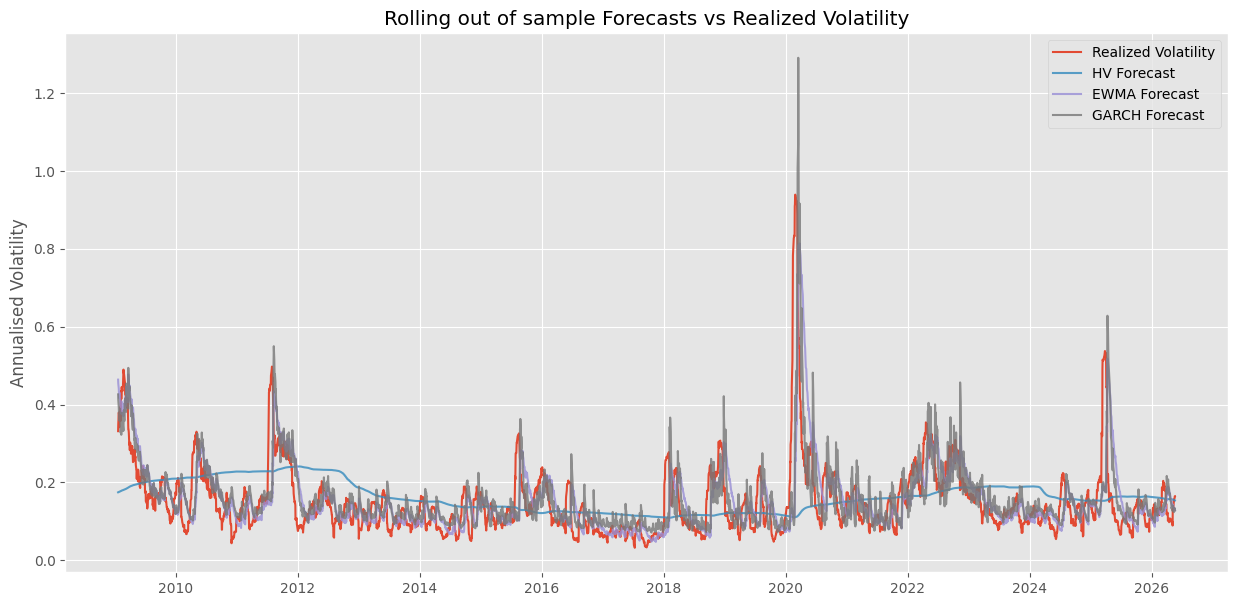

In [8]:
plt.figure(figsize=(15, 7))

plt.plot(
    oos.index,
    oos["actual"],
    label="Realized Volatility",
    linewidth=1.5
)

plt.plot(
    oos.index,
    oos["hv"],
    label="HV Forecast",
    alpha=0.8
)

plt.plot(
    oos.index,
    oos["ewma"],
    label="EWMA Forecast",
    alpha=0.8
)

plt.plot(
    oos.index,
    oos["garch"],
    label="GARCH Forecast",
    alpha=0.8
)

plt.legend()
plt.title("Rolling out of sample Forecasts vs Realized Volatility")
plt.ylabel("Annualised Volatility")
plt.savefig("images/nb7_oos_all_models.png", dpi=150, bbox_inches="tight")
plt.show()

## Comments


I laughed a little when I saw HVF. But nonetheless it looks like GARCH and EWMA track the trajectory pretty closely. Maybe GARCH reacts to recent changes faster, while EWMA lacks. Right now I can't really conlcude much. I must look at smaller periods, particularly during crisis to make some conclusions.

# Experiment 6: Accuracy Metrics

Here I compute RMSE, MAE and MAPE for each model across the full out of sample period. These are most valuable for comparing performance.

In [9]:
def compute_metrics(actual, forecast, name):

    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mae = mean_absolute_error(actual, forecast)
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100

    return {"Model": name, "RMSE": rmse, "MAE": mae, "MAPE": mape}


results = pd.DataFrame(
    [
        compute_metrics(oos["actual"], oos["hv"],    "Historical Volatility"),
        compute_metrics(oos["actual"], oos["ewma"],  "EWMA"),
        compute_metrics(oos["actual"], oos["garch"], "GARCH")
    ]
)

results

,Model,RMSE,MAE,MAPE
0,Historical Volatility,0.097724,0.066798,52.039191
1,EWMA,0.086579,0.053430,37.364258
2,GARCH,0.081926,0.051911,37.518929


## Comments

We can see a clear improvement from HV to EWMA to GARCH. However, for the MAPE, the performance of GARCH is marginally worse. 
Nonetheless, we can conclude that more fancy volatility dynamics lead to better oos predictions.

But remember our results from previous notebooks were 
- HVF : RMSE=0.102388 MAE=0.059998 
- EWMA : RMSE=0.088104 MAE=0.053040
- GARCH : RMSE	0.083983 MAE=0.051915

For HVF somehow we are lower but for EWMA and GARCH the errors have increased so they were most likely overfitting. This is exactly why oos is better and essential.

# Experiment 7: QLIKE Loss Function

RMSE and MAE are the standard metrics but they treat overprediction and underprediction symmetrically. In finance this is not ideal. Underestimating risk is more costly than overestimating it because it can lead to huge losses.

The QLIKE loss function is specifically designed for volatility forecast evaluation. It comes from the quasi-likelihood of a normal distribution and is asymmetric such that it penalises underestimation more heavily.

In [10]:
def qlike(actual, forecast):
    # QLIKE loss: log(forecast^2) + actual^2 / forecast^2
    # lower is better
    return np.mean(
        np.log(forecast**2) + (actual**2) / (forecast**2)
    )


qlike_results = pd.DataFrame(
    {
        "Model": [
            "Historical Volatility",
            "EWMA",
            "GARCH"
        ],
        "QLIKE": [
            qlike(oos["actual"], oos["hv"]),
            qlike(oos["actual"], oos["ewma"]),
            qlike(oos["actual"], oos["garch"])
        ]
    }
)

qlike_results

,Model,QLIKE
0,Historical Volatility,-2.248241
1,EWMA,-2.505638
2,GARCH,-2.563198


## Comments

The QLIKE loss function is commonly used in academic research on volatility forecasting. It is derived from the Gaussian quasi-likelihood. Models that produce lower QLIKE scores are penalised more for dangerous underestimation of risk which is what we care most too.

More negative means better and so the ranking here GARCH outperforms EWMA and both of them outperform Historical Volatility. I think this the best proof og GARCH being better than everything we have tried so far. 


# Experiment 8: Forecast Error Distributions

Beyond average metrics I want to understand the distribution of errors. This will help me see if my mode is prone to large outlier errors. If the errors are symmetric and if one model consistently underestimate or overestimate volatility.

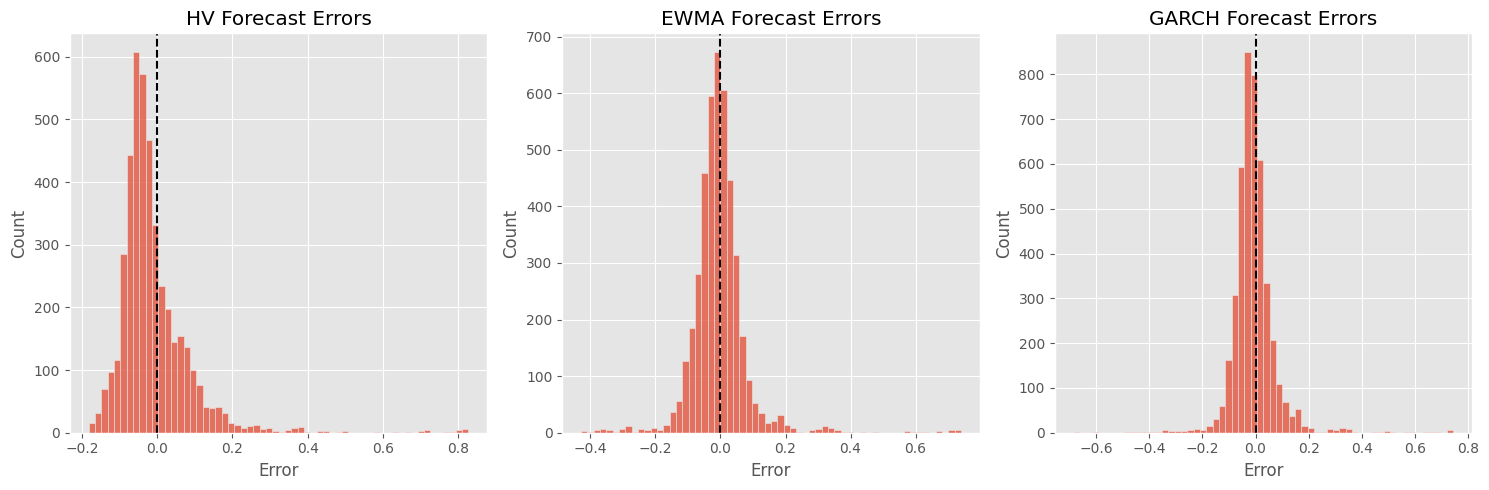

In [11]:
oos["err_hv"]    = oos["actual"] - oos["hv"]
oos["err_ewma"]  = oos["actual"] - oos["ewma"]
oos["err_garch"] = oos["actual"] - oos["garch"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, name in zip(
    axes,
    ["err_hv", "err_ewma", "err_garch"],
    ["HV", "EWMA", "GARCH"]
):

    sns.histplot(
        oos[col].dropna(),
        bins=60,
        ax=ax
    )

    ax.axvline(0, color="black", linestyle="--")
    ax.set_title(f"{name} Forecast Errors")
    ax.set_xlabel("Error")

plt.tight_layout()
plt.savefig("images/nb7_error_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## Comments

All of our forecasts have leftward skew. This means they are overestimating. So atleast they are not understimating which is most risky. Now, even in the overestimation, HVF does it the most, GARCH the least. HVF has a wider didtribution which implies less precision. A simple bias is still fixable, but variance is harder to fix.


# Case Study: Crisis Period Performance

The most important test for any forecasting model is how it behaves when it matters most. I want to look at the COVID crash of 2020 and the 2008 Global Financial Crisis and examine out of sample performance specifically during those periods.

These are the moments when inaccurate volatility forecasts cause the most financial damage. So it is best to test throughly here to perform better during future crashes. 

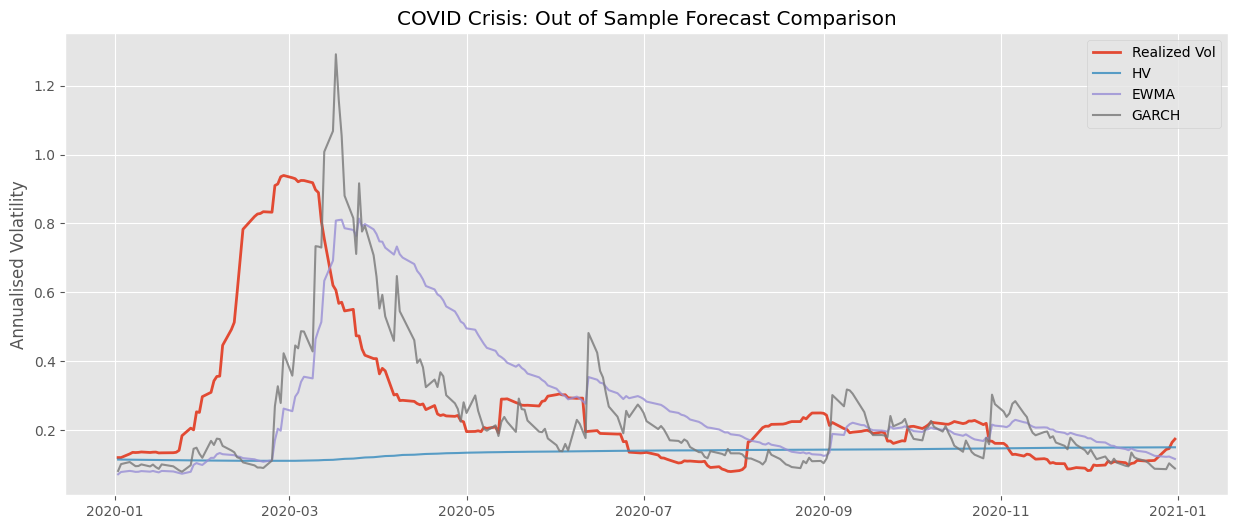

COVID Crisis Performance
   Model      RMSE       MAE       MAPE
0     HV  0.254473  0.148827  42.758285
1   EWMA  0.239125  0.162133  61.953732
2  GARCH  0.208943  0.131694  44.583731


In [13]:
# COVID crash

covid = oos.loc["2020-01-01":"2021-01-01"]

if len(covid) > 0:

    plt.figure(figsize=(15, 6))

    plt.plot(covid.index, covid["actual"], label="Realized Vol", linewidth=2)
    plt.plot(covid.index, covid["hv"],     label="HV",    alpha=0.8)
    plt.plot(covid.index, covid["ewma"],   label="EWMA",  alpha=0.8)
    plt.plot(covid.index, covid["garch"],  label="GARCH", alpha=0.8)

    plt.legend()
    plt.title("COVID Crisis: Out of Sample Forecast Comparison")
    plt.ylabel("Annualised Volatility")
    plt.savefig("images/nb7_covid_oos.png", dpi=150, bbox_inches="tight")
    plt.show()

    covid_metrics = pd.DataFrame(
        [
            compute_metrics(covid["actual"], covid["hv"],    "HV"),
            compute_metrics(covid["actual"], covid["ewma"],  "EWMA"),
            compute_metrics(covid["actual"], covid["garch"], "GARCH")
        ]
    )

    print("COVID Crisis Performance")
    print(covid_metrics)

## Comments

- Historical volatility will lags so badly because it averages over a long window. 
- EWMA should reacts faster but not fast enough. 
- GARCH has the least lag but still tends to overshoot

As before, RMSE reduces along the table, so the rankings still remain the same. 

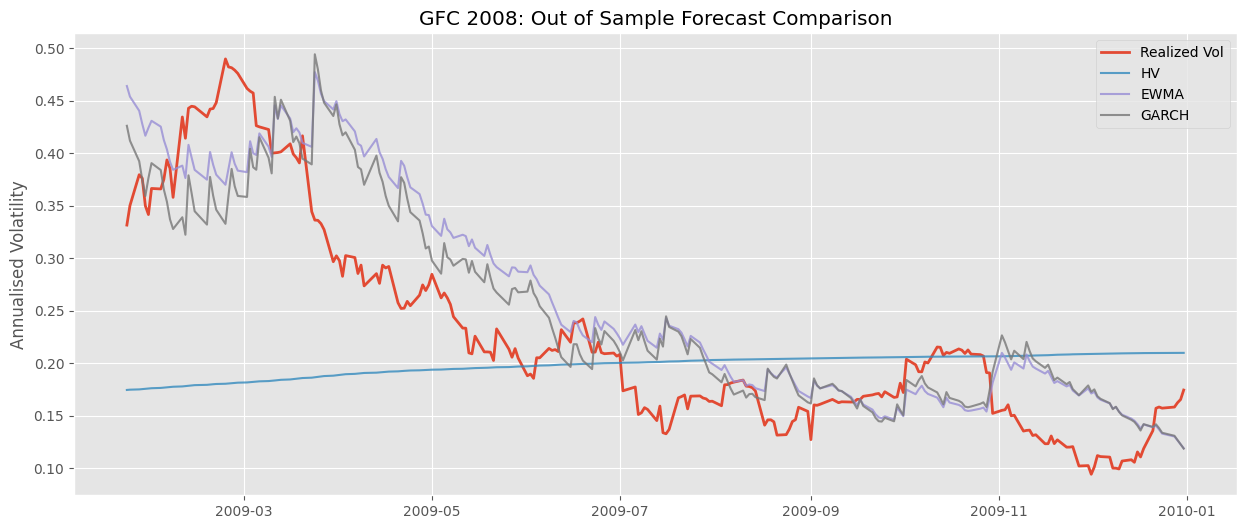

GFC 2008 Performance
   Model      RMSE       MAE       MAPE
0     HV  0.113623  0.082581  35.054146
1   EWMA  0.064721  0.054039  26.499499
2  GARCH  0.060678  0.050078  24.593795


In [14]:
# 2008 Global Financial Crisis

gfc = oos.loc["2008-01-01":"2009-12-31"]

if len(gfc) > 0:

    plt.figure(figsize=(15, 6))

    plt.plot(gfc.index, gfc["actual"], label="Realized Vol", linewidth=2)
    plt.plot(gfc.index, gfc["hv"],     label="HV",    alpha=0.8)
    plt.plot(gfc.index, gfc["ewma"],   label="EWMA",  alpha=0.8)
    plt.plot(gfc.index, gfc["garch"],  label="GARCH", alpha=0.8)

    plt.legend()
    plt.title("GFC 2008: Out of Sample Forecast Comparison")
    plt.ylabel("Annualised Volatility")
    plt.savefig("images/nb7_gfc_oos.png", dpi=150, bbox_inches="tight")
    plt.show()

    gfc_metrics = pd.DataFrame(
        [
            compute_metrics(gfc["actual"], gfc["hv"],    "HV"),
            compute_metrics(gfc["actual"], gfc["ewma"],  "EWMA"),
            compute_metrics(gfc["actual"], gfc["garch"], "GARCH")
        ]
    )

    print("GFC 2008 Performance")
    print(gfc_metrics)

## Comments

The 2008 crisis was longer than COVID. Volatility remained high for a year rather than spiking and recovering within months. This is a helpful test for not just how quickly a model detects a regime change but how well it sustains elevated forecasts through a prolonged stress period. Models that revert too quickly to long run average will underestimate risk throughout the crisis, this is exactly what we'd like to avoid.

# Experiment 9: Performance Across Market Regimes

Rather than just picking specific crisis dates, I want to partition the full out of sample period by volatility level and see how each model performs in each regime. This gives a better picture of where each model excels and where it struggles.

In [15]:
# define regimes by volatility level
# low= below 15%, medium= 15-30%, high= above 30%

oos["regime"] = pd.cut(
    oos["actual"],
    bins=[0, 0.15, 0.30, 1.0],
    labels=["Low", "Medium", "High"]
)

regime_perf = []

for regime in ["Low", "Medium", "High"]:

    subset = oos[oos["regime"] == regime]

    if len(subset) < 20:
        continue

    for model, col in [("HV", "hv"), ("EWMA", "ewma"), ("GARCH", "garch")]:

        rmse = np.sqrt(mean_squared_error(subset["actual"], subset[col]))

        regime_perf.append(
            {
                "Regime": regime,
                "Model": model,
                "RMSE": rmse,
                "N": len(subset)
            }
        )

regime_df = pd.DataFrame(regime_perf)
regime_df

,Regime,Model,RMSE,N
0,Low,HV,0.067910,2744
1,Low,EWMA,0.048980,2744
2,Low,GARCH,0.047139,2744
3,Medium,HV,0.065233,1382
4,Medium,EWMA,0.085295,1382
5,Medium,GARCH,0.077209,1382
6,High,HV,0.314819,233
7,High,EWMA,0.262351,233
8,High,GARCH,0.253061,233


## Comments

During highs and lows, the rankings are same but suprisingly when there is medium volatility, HVF outperforms both the other by huge margin. I wonder if combinations are better than just one model. 

# Conclusion

This notebook established the first evaluation of all three models together. Sample comparisons from earlier notebooks were necessary for understanding model behaviour but they were always going to flatter performance. Out of sample evaluation removes the bias.

The ranking after this notebook are GARCH>EWMA>HVF. But we need to be cautious because no single model donimates throguhout. During medium volatility, the rankings reverse.

This motivates the next notebook where I shall try to combine the regime information from the HMM (notebook 6) with the GARCH forecast to build a model that adapts to the current market regime.